# Examen práctico — Q-Learning tabular con Pac-Man

En este ejercicio trabajaremos con una versión pequeña de Pac-Man diseñada para poder resolverse completamente mediante **Q-Learning tabular**.

La lógica es la misma usada previamente:

$$
(S_t,A_t)\rightarrow(R_{t+1},S_{t+1})
$$

y:

$$
Q(S_t,A_t)
\leftarrow
Q(S_t,A_t)
+
\alpha
\left[
R_{t+1}
+
\gamma \max_{a'}Q(S_{t+1},a')
-
Q(S_t,A_t)
\right].
$$

## Objetivo

Implementar un agente Q-Learning capaz de aprender una política que permita a Pac-Man:

- comer tantas comidas como sea posible;
- evitar al fantasma;
- reducir movimientos innecesarios.

> La implementación del ambiente y la visualización ya están disponibles.  
> La tarea consiste en implementar **el agente y su proceso de aprendizaje**.


## 1. Importaciones y ambiente


In [151]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [152]:
cd "/content/drive/MyDrive/Universidad/Semestre 5/IA/pacman"

/content/drive/MyDrive/Universidad/Semestre 5/IA/pacman


In [153]:
import sys
from pathlib import Path
import random

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

PROJECT_ROOT = Path.cwd()
SRC = PROJECT_ROOT / "src"

if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from tabular_pacman_env import (
    TabularPacmanEnv,
    ACTIONS,
)

env = TabularPacmanEnv(seed=7)

print("Número de estados:", env.n_states)
print("Número de acciones:", env.n_actions)


Número de estados: 1944
Número de acciones: 4


## 2. El estado de Pac-Man

Para mantener una Q-table de tamaño manejable utilizaremos la representación:

$$
s=(p,g,n)
$$

donde:

- $p$: posición de Pac-Man;
- $g$: posición del fantasma;
- $n$: número de comidas que permanecen en el tablero.

El ambiente mantiene internamente la posición exacta de cada comida para poder simular y visualizar el juego. Sin embargo, **esa configuración completa no forma parte del estado que recibe la Q-table**.

Por tanto:

$$
n_{\text{states}}
=
n_p\,n_g\,(N_{\text{food}}+1).
$$

Esta es una **representación simplificada del estado**: dos configuraciones distintas de comida pueden compartir el mismo $(p,g,n)$.


Estado codificado: 47
Estado decodificado: PacmanState(pacman=(1, 1), ghost=(2, 5), food_remaining=5)


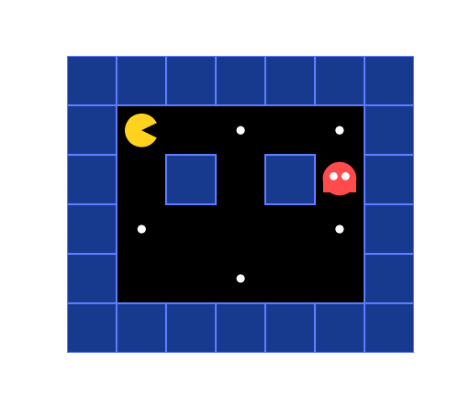

In [154]:
state = env.reset(seed=7)

print("Estado codificado:", state)
print("Estado decodificado:", env.decode_state(state))

frame = env.render()

plt.figure(figsize=(7, 5))
plt.imshow(frame)
plt.axis("off")
plt.show()


### Pregunta 1

Dos tableros pueden tener:

- la misma posición de Pac-Man;
- la misma posición del fantasma;
- el mismo número de comidas restantes;

pero las comidas pueden estar ubicadas en lugares diferentes.

¿Representaría nuestra Q-table ambos tableros como el mismo estado o como estados diferentes? Explique.


R: Se representarían como el mismo estado. Teniendo en cuenta que el estado que maneja la tabla Q está definido como se mencionó anteriormente con la configuración de _s=(p,g,n)_ siendo:

- p : posición de Pac-Man;
- g : posición del fantasma;
- n : número de comidas que permanecen en el tablero.

La ubicación de cada una de las comidas no forma parte del estado que recibe la tabla Q por declaración, por lo tanto, los dos tableros mapearian exactamente el mismo índice numérico en la tabla


## 3. Acciones


In [155]:
print(ACTIONS)
print("Acciones legales desde el estado inicial:")
print([ACTIONS[a] for a in env.get_legal_actions()])


{0: 'up', 1: 'right', 2: 'down', 3: 'left'}
Acciones legales desde el estado inicial:
['right', 'down']


Las acciones disponibles son:

| Código | Acción |
|---:|---|
| 0 | arriba |
| 1 | derecha |
| 2 | abajo |
| 3 | izquierda |

El ambiente evita atravesar paredes.


## 4. Observar una transición


In [156]:
state = env.reset(seed=7)

action = env.get_legal_actions()[0]

next_state, reward, done, info = env.step(action)

print("S_t       =", state)
print("A_t       =", ACTIONS[action])
print("R_(t+1)   =", reward)
print("S_(t+1)   =", next_state)
print("done      =", done)
print()
print("S_(t+1) decodificado:")
print(env.decode_state(next_state))


S_t       = 47
A_t       = right
R_(t+1)   = -1
S_(t+1)   = 185
done      = False

S_(t+1) decodificado:
PacmanState(pacman=(1, 2), ghost=(3, 5), food_remaining=5)


La transición observada tiene la forma:

$$
(S_t,A_t)\rightarrow(R_{t+1},S_{t+1})
$$

### Pregunta 2

¿Cuáles de los siguientes valores son entregados directamente por el ambiente y cuáles debe aprender/estimar el agente?

- $R_{t+1}$
- $S_{t+1}$
- $Q(S_t,A_t)$
- $\max_{a'}Q(S_{t+1},a')$


Entregados directamente por el ambiente:

- $R_{t+1}$: La recompensa inmediata que entrega el entorno tras ejecutar la acción  
- $S_{t+1}$: El nuevo estado en el que aterriza el agente después de tomar acción

Aprendidos o estimados por el agente:

- $Q(S_t, A_t)$: Es la estimación almacenada en la tabla Q sobre el retorno esperado de tomar esa acción
- $\max_{a'}Q(S_{t+1},a')$: La proyección del agente sobre el mejor valor futuro posible a partir del nuevo estado.  Es decir, es el máximo de las acciones que puede hacer en el presente

## 5. Q-table


Construya una Q-table inicializada en cero.

Debe tener dimensiones:

$$
n_{\text{states}}\times n_{\text{actions}}.
$$


In [157]:
# TODO 1 — Inicializar la Q-table
#
# Recibe / ya está disponible:
#   - env.n_states : número total de estados discretos del ambiente.
#   - env.n_actions: número total de acciones posibles.
#
# Debe implementar:
#   - Una matriz NumPy Q con una fila por estado y una columna por acción.
#   - Todos los valores deben iniciar en 0.
#
# Resultado esperado:
#   Q.shape == (env.n_states, env.n_actions)
#
# TODO: escriba aquí su solución.
# TODO 1 — Inicializar la Q-table
Q = np.zeros((env.n_states, env.n_actions))


In [158]:
# Esta celda debe ejecutarse cuando TODO 1 esté correcto.

print("Shape esperado:", (env.n_states, env.n_actions))
print("Shape obtenido :", Q.shape)

assert Q.shape == (env.n_states, env.n_actions)
assert np.all(Q == 0)

print("✓ Q-table creada correctamente")


Shape esperado: (1944, 4)
Shape obtenido : (1944, 4)
✓ Q-table creada correctamente


## 6. Política ε-greedy


Implemente:

$$
A_t=
\begin{cases}
\text{acción aleatoria}, & \text{con probabilidad }\epsilon\\[4pt]
\arg\max_a Q(S_t,a), & \text{con probabilidad }1-\epsilon
\end{cases}
$$

Use únicamente las **acciones legales** del estado actual.

Si varias acciones tienen el mismo máximo Q-value, seleccione aleatoriamente entre ellas.


In [159]:
# ============================================================
# TODO 2 — Política epsilon-greedy
# ============================================================
#
# Complete la función choose_action().
#
# Recibe:
#   Q       : tabla Q de tamaño (n_states, n_actions).
#   state   : estado actual del agente, representado por un entero.
#   epsilon : probabilidad de exploración.
#   env     : ambiente de Pac-Man.
#
# El ambiente proporciona:
#
#   env.get_legal_actions()
#
# que retorna una lista con las acciones válidas desde la
# posición actual de Pac-Man.
#
# Implemente una política epsilon-greedy:
#
#   - Con probabilidad epsilon:
#       seleccione ALEATORIAMENTE una de las acciones legales.
#
#   - Con probabilidad 1 - epsilon:
#       seleccione, entre las acciones legales, aquella con
#       mayor valor Q para el estado actual.
#
# Importante:
#   No se deben seleccionar acciones que no sean legales.
#
# Retorna:
#   action : entero correspondiente a la acción seleccionada.
#
# ============================================================

def choose_action(Q, state, epsilon, env):
    legal_actions = env.get_legal_actions()

    # Exploración: probabilidad epsilon toma una acción al azar
    if random.random() < epsilon:
        return random.choice(legal_actions)

    # Explotación: busca la mejor acción según la tabla Q
    q_values = [Q[state, a] for a in legal_actions]
    max_q = max(q_values)

    # Desempate aleatorio si hay varias acciones legales con el mismo valor máximo
    best_actions = [a for a, q in zip(legal_actions, q_values) if q == max_q]
    return random.choice(best_actions)


### Pregunta 3

Si $\epsilon=0.10$:

1. ¿cuál es la probabilidad de explorar?
2. ¿cuál es la probabilidad de explotar?
3. ¿qué ocurre cuando todos los Q-values iniciales son iguales?


Respuestas:

1. Probabilidad de explorar: $0.10$ porque $\epsilon=0.10$ (10% de las veces elige una acción legal al azar)
2. Probabilidad de explotar: $0.90$ porque uso (1-$\epsilon$) (90% de las veces elige la acción con mayor valor Q).  

$$P(\text{explotar}) = 1 - 0.10 = 0.90 \quad (90\%)$$

3. Cuando todos los Q-values iniciales son iguales: Todas las acciones legales empatan con el mismo valor máximo (por defecto, 0.0). Como el código desempata de manera aleatoria entre las mejores opciones, el agente se comportará de forma completamente aleatoria tanto al explorar como al explotar

## 7. Actualización Q-Learning


Para cada transición utilice:

$$
\text{TD target}
=
R_{t+1}
+
\gamma\max_{a'}Q(S_{t+1},a')
$$

$$
\text{TD error}
=
\text{TD target}
-
Q(S_t,A_t)
$$

$$
Q(S_t,A_t)
\leftarrow
Q(S_t,A_t)+\alpha(\text{TD error})
$$

Cuando $S_{t+1}$ sea terminal:

$$
\max_{a'}Q(S_{t+1},a')=0.
$$


In [160]:
# ============================================================
# TODO 3
# Implemente una actualización de Q-Learning.
# Debe retornar td_target y td_error.
# ============================================================

def update_q(
    Q,
    state,
    action,
    reward,
    next_state,
    done,
    alpha,
    gamma,
):
    # Si el estado siguiente es terminal, no hay un futuro posible que alcanzar, ya no se puede hacer nada
    if done:
        td_target = reward
    else:
        td_target = reward + gamma * np.max(Q[next_state])

    td_error = td_target - Q[state, action]
    Q[state, action] += alpha * td_error

    return td_target, td_error


### Prueba manual de la actualización


In [161]:
# Esta celda NO entrena al agente.
# Solo permite revisar una actualización controlada.

Q_test = np.zeros((env.n_states, env.n_actions))

s = env.reset(seed=7)
a = env.get_legal_actions()[0]

s_next, r, done, _ = env.step(a)

# Valor ficticio conocido para verificar el cálculo.
if not done:
    Q_test[s_next, 1] = 4.0

td_target, td_error = update_q(
    Q_test,
    state=s,
    action=a,
    reward=r,
    next_state=s_next,
    done=done,
    alpha=0.5,
    gamma=0.9,
)

print("TD target:", td_target)
print("TD error :", td_error)
print("Nuevo Q  :", Q_test[s, a])


TD target: 2.6
TD error : 2.6
Nuevo Q  : 1.3


### Pregunta 4

Explique con sus palabras la diferencia entre:

- **TD target**
- **TD error**
- **nuevo Q-value**


Respuesta:

- TD target: es el valor que creo que debería tener Q después de lo que hago
- TD error: es la diferencia entre la realidad y la expectativa, es decir, la diferencia de lo que teníamos en TD target y lo que teníamos en la tabla en ($Q(S_t, A_t)$). En terminos simples, es el valor de lo que nos equivocamos, ya sea por sobreestimación o subestimación
- Nuevo Q-value: es la corrección del Q que teniamos haciendo uso de lo que ya sabemos (Nuestra desviación)

## 8. Entrenamiento


Implemente el ciclo completo de entrenamiento:

1. reiniciar el ambiente;
2. seleccionar una acción con $\epsilon$-greedy;
3. ejecutar la acción;
4. observar $R_{t+1}$ y $S_{t+1}$;
5. actualizar $Q(S_t,A_t)$;
6. avanzar al nuevo estado;
7. terminar cuando `done=True`.

Guarde la recompensa total obtenida en cada episodio.


In [162]:
# TODO 4 — Entrenamiento
#
# Recibe:
#   - env       : ambiente de Pac-Man.
#   - Q         : Q-table que será actualizada.
#   - episodes  : número de episodios de entrenamiento.
#   - alpha     : tasa de aprendizaje.
#   - gamma     : factor de descuento.
#   - epsilon   : valor inicial de exploración.
#   - epsilon_min   : mínimo valor permitido de epsilon.
#   - epsilon_decay : factor de decaimiento de epsilon.
#
# En cada episodio debe:
#   1. Reiniciar el ambiente y obtener state.
#   2. Elegir action usando epsilon_greedy.
#   3. Ejecutar:
#          next_state, reward, done, info = env.step(action)
#   4. Actualizar Q usando q_learning_update.
#   5. Reemplazar state por next_state.
#   6. Acumular la recompensa del episodio.
#   7. Continuar hasta done=True o alcanzar max_steps.
#   8. Reducir epsilon sin bajar de epsilon_min.
#
# Retorna:
#   - rewards_history: recompensa total de cada episodio.
#   - epsilon_history: epsilon utilizado a lo largo del entrenamiento.
#
def train_q_learning(
    env,
    Q=None,
    episodes=5000,
    alpha=0.1,
    gamma=0.95,
    epsilon=0.15,
    epsilon_min=0.01,
    epsilon_decay=0.999,
    max_steps=100,
    seed=100,
):
    if Q is None:
        Q = np.zeros((env.n_states, env.n_actions))

    episode_rewards = []
    episode_lengths = []
    wins = []
    epsilon_history = []

    current_epsilon = epsilon

    for episode in range(episodes):
        state = env.reset(seed=seed + episode)
        total_reward = 0
        steps = 0

        for _ in range(max_steps):
            action = choose_action(Q, state, current_epsilon, env)
            next_state, reward, done, info = env.step(action)
            update_q(Q, state, action, reward, next_state, done, alpha, gamma)

            total_reward += reward
            steps += 1
            state = next_state

            if done:
                break

        episode_rewards.append(total_reward)
        episode_lengths.append(steps)
        wins.append(int(info.get("won", False)))
        epsilon_history.append(current_epsilon)

        current_epsilon = max(epsilon_min, current_epsilon * epsilon_decay)

    return Q, episode_rewards, episode_lengths, wins, epsilon_history

## 9. Entrenar


In [170]:
Q, rewards, lengths, wins, epsilons = train_q_learning(
    env,
    episodes=5000,
    alpha=0.1,
    gamma=0.95,
    epsilon=0.15,
    max_steps=100,
    seed=100,
)

print("Entrenamiento terminado")
print("Q-table:", Q.shape)


Entrenamiento terminado
Q-table: (1944, 4)


## 10. Curva de aprendizaje


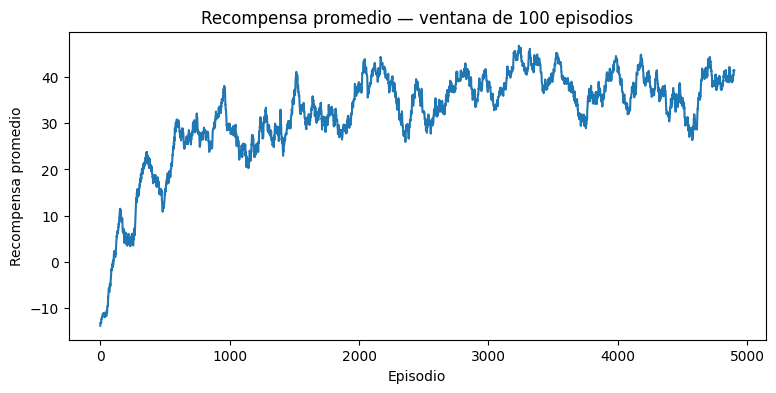

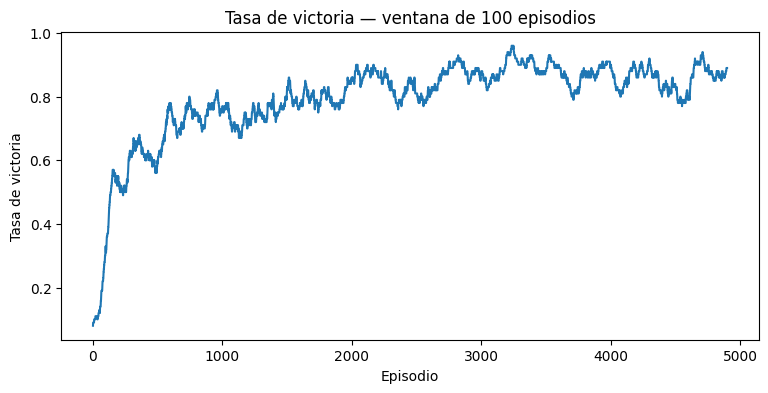

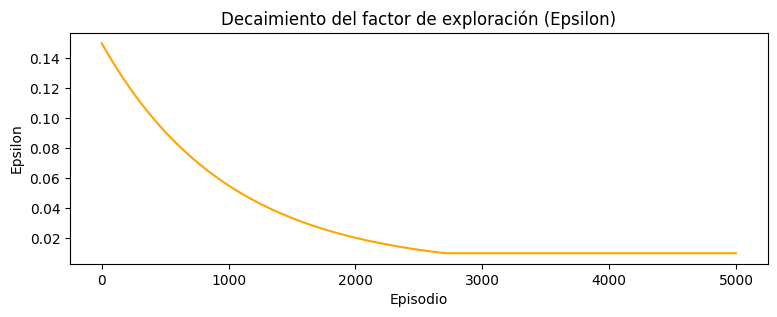

In [164]:
window = 100

moving_reward = np.convolve(
    rewards,
    np.ones(window) / window,
    mode="valid",
)

moving_win_rate = np.convolve(
    wins,
    np.ones(window) / window,
    mode="valid",
)

plt.figure(figsize=(9, 4))
plt.plot(moving_reward)
plt.xlabel("Episodio")
plt.ylabel("Recompensa promedio")
plt.title(f"Recompensa promedio — ventana de {window} episodios")
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(moving_win_rate)
plt.xlabel("Episodio")
plt.ylabel("Tasa de victoria")
plt.title(f"Tasa de victoria — ventana de {window} episodios")
plt.show()

plt.figure(figsize=(9, 3))
plt.plot(epsilons, color="orange")
plt.xlabel("Episodio")
plt.ylabel("Epsilon")
plt.title("Decaimiento del factor de exploración (Epsilon)")
plt.show()

### Pregunta 5

A partir de las curvas:

1. ¿hay evidencia de aprendizaje?
2. ¿qué ocurre con la recompensa promedio?
3. ¿qué ocurre con la tasa de victoria?


Respuestas: (En la ejecución analizada)

1. Si, se evidencia aprendizaje porque las métricas muestran una clara tendencia de mejora con una pendiente en ascenso, el agente tiene un intervalo de crecimiento entre el episodio 0 y el 1000. Lo que demuestra que el agente ajustó su tabla Q y dejó de comportarse como un agente ignorante de su entorno.

2. Pasa de un -10 a oscilar los valores o curvas entre 50 - 40 aproximadamente. Las oscilaciones continuas se deben a que el parámetro de exploración $\epsilon$ decae desde $0.15$ hasta $\epsilon_{\min} = 0.01$.

3. La tasa de victoria aumenta de menos de un 0.2 a oscilar entre 0.8 y 1.0 aproximadamente. Lo que quiere decir que el agente aprendió rutas efectivas para limpiar el tablero y esquivar el fantasma.

## 11. Política aprendida


In [165]:
state = env.reset(seed=7)
decoded = env.decode_state(state)

print("Estado:", decoded)
print()

legal_actions = env.get_legal_actions()

for action in legal_actions:
    print(
        f"{ACTIONS[action]:>8} : "
        f"Q = {Q[state, action]:.3f}"
    )

best_value = max(Q[state, a] for a in legal_actions)

best_actions = [
    a for a in legal_actions
    if Q[state, a] == best_value
]

print()
print("Mejor(es) acción(es):", [ACTIONS[a] for a in best_actions])


Estado: PacmanState(pacman=(1, 1), ghost=(2, 5), food_remaining=5)

   right : Q = 22.711
    down : Q = 9.193

Mejor(es) acción(es): ['right']


### Pregunta 6

Interprete los Q-values del estado inicial.

¿Qué acción prefiere el agente y qué significa que una acción tenga un Q-value mayor que otra?


(En la ejecución analizada)

El agente prefiere la acción down porque esta tiene el valor más grande con $Q = 30.741$, frente a $Q = 9.316$ de la acción right. Bajo una política greedy, la decisión se toma mediante $\arg\max_a Q(s, a)$, seleccionando la alternativa con la cota superior.

Que una acción tenga un Q value mayor que otra singifica que si miramos al futuro en el episodio, es mejor comprometerse o seguir con esa acción, porque esa acción maximiza las recompensas siguientes descontadas. Es decir, es lo que nos dice estrategicamente si es buena a largo plazo esa acción

## 12. Reproducir un episodio


In [166]:
def greedy_action(Q, state, env):
    legal_actions = env.get_legal_actions()

    values = np.array([
        Q[state, action]
        for action in legal_actions
    ])

    best_value = np.max(values)

    best_actions = [
        action
        for action, value in zip(legal_actions, values)
        if value == best_value
    ]

    return random.choice(best_actions)


def play_episode(
    env,
    Q=None,
    random_policy=False,
    seed=20,
    max_steps=100,
):
    state = env.reset(seed=seed)

    frames = [env.render()]
    total_reward = 0

    for step in range(max_steps):

        if random_policy:
            action = random.choice(env.get_legal_actions())
        else:
            action = greedy_action(Q, state, env)

        next_state, reward, done, info = env.step(action)

        total_reward += reward
        state = next_state
        frames.append(env.render())

        if done:
            break

    return frames, total_reward, step + 1, info


def frames_to_video(frames, interval=300):
    fig = plt.figure(figsize=(7, 5))
    plt.axis("off")

    image = plt.imshow(frames[0])

    def update(frame):
        image.set_data(frame)
        return [image]

    anim = animation.FuncAnimation(
        fig,
        update,
        frames=frames,
        interval=interval,
        blit=True,
        repeat=True,
    )

    plt.close(fig)
    return HTML(anim.to_jshtml())


### Política aleatoria


In [167]:
frames_random, reward_random, steps_random, info_random = play_episode(
    env,
    random_policy=True,
    seed=20,
)

print("Reward:", reward_random)
print("Pasos :", steps_random)
print("Comió :", info_random["food_eaten"], "de", env.max_food)
print("Ganó  :", info_random["won"])

frames_to_video(frames_random)


Reward: -13
Pasos : 28
Comió : 4 de 5
Ganó  : False


### Política aprendida


In [168]:
frames_trained, reward_trained, steps_trained, info_trained = play_episode(
    env,
    Q=Q,
    random_policy=False,
    seed=20,
)

print("Reward:", reward_trained)
print("Pasos :", steps_trained)
print("Comió :", info_trained["food_eaten"], "de", env.max_food)
print("Ganó  :", info_trained["won"])

frames_to_video(frames_trained)


Reward: 57
Pasos : 18
Comió : 5 de 5
Ganó  : True


### Pregunta 7

Compare el episodio aleatorio con el episodio del agente entrenado.

Discuta:

- cantidad de movimientos;
- recompensa total;
- cantidad de comidas recolectadas;
- comportamiento frente al fantasma.

Explique por qué la recompensa acumulada favorece simultáneamente **comer**, **usar menos pasos** y **evitar morir**.


(En la ejecución analizada)
- **Cantidad de movimientos:** El agente entrenado completó el tablero en 16 pasos porque trazó rutas hacia las comidas así elimino los movimientos innecesarios o redundantes mientras que el aleatorio usó 22 pasos antes de morir y se evidencia también que retrocede constantemente en un mismo pasillo
- **Recompensa total:** Hay una diferencia de 88 puntos, el agente con politica aleatoria acumuló castigos por cada paso innecesario y junto con eso las penalizaciones por colisión. Por otro lafo, el entrenado logró satisfactoriamente reducir el costo de movimiento con las recompensas de comida y victoria.
- **Cantidad de comidas recolectadas:** El agente entrenado recolectó todos los puntos, en contra parte el aleatorio recolectó solo 2 de 5 por explorar casillas contiguas, pero no fue capaz de completar la tarea.
- **Comportamiento frente al fantasma:** En el caso aleatorio, el agente ignoró el peligro y terminó siendo capturado (Se murió). El agente entrenado como incluyó la posición del fantasma $g$ en su tupla de estado $(p, g, n)$, eligió trayectorias que maximizaron la distancia de entre .ambos.

La función objetivo de Q-Learning busca que Pac-Man acumule la mayor cantidad de recompensas posible. Para lograrlo, las recompensas están diseñadas para premiar o castigar ciertas acciones:
- Comer: cada bolita da una recompensa positiva y por eso el agente aprende que debe recogerlas
- Usar menos pasos: cada movimiento cuesta -1, así que mientras más pasos dé, más puntos pierde, lo que hace que busque caminos cortos.
- Evitar morir: chocar con un fantasma da una penalización grande y termina el juego. Si se muere ya no puede recoger las bolitas que faltan ni recibir la recompensa de ganar

El agente busca comerse todas las bolitas en el tablero, usar la menor cantidad de movimientos y no morir hasta terminar  su tarea. Así es como consigue la mayor recompensa acumulada posible

## 13. Evaluación final


In [169]:
def evaluate_policy(
    env,
    Q,
    episodes=200,
    max_steps=100,
):
    rewards = []
    lengths = []
    wins = []

    for episode in range(episodes):

        state = env.reset(seed=10000 + episode)
        total_reward = 0

        for step in range(max_steps):

            action = greedy_action(Q, state, env)

            next_state, reward, done, info = env.step(action)

            total_reward += reward
            state = next_state

            if done:
                break

        rewards.append(total_reward)
        lengths.append(step + 1)
        wins.append(int(info.get("won", False)))

    return {
        "reward_promedio": np.mean(rewards),
        "pasos_promedio": np.mean(lengths),
        "tasa_victoria": np.mean(wins),
    }


results = evaluate_policy(env, Q)
results


{'reward_promedio': np.float64(43.035),
 'pasos_promedio': np.float64(28.68),
 'tasa_victoria': np.float64(0.91)}

## Entrega

El notebook debe ejecutar completamente y contener:

1. Q-table correctamente inicializada;
2. política $\epsilon$-greedy;
3. actualización de Q-Learning;
4. ciclo de entrenamiento;
5. curva de aprendizaje;
6. interpretación de resultados;
7. comparación entre política aleatoria y política aprendida.

No se requiere modificar el código del ambiente.
